In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import sys, os, time

sys.path.append(os.path.abspath("../src"))
from SegmentationAndLabelingProblem import SegmentationAndLabeling

## Model setup

This is an example of a use case that is close to the formulation of the Correlation Clustering Problem: given an arbitrary graph with equivalent nodes (i.e., the number of labels is set to 1 and the corresponding label weight set to zero) and randomly weighted (positive and negative) edges, combine the nodes into clusters such that the inter-node interactions are minimized.

In [2]:
# Generate a graph with randomly weighted connectivity
num_nodes = 6
num_labels = 1

# random model parameters
seed = 12345
np.random.seed(seed)

# alpha_dc
A = np.zeros((num_nodes, num_labels))
# A = np.random.uniform(-1, 1, size=(num_nodes, num_labels))
A = np.round(A, 1)

# beta_dc_d'c'
B = np.zeros((num_nodes, num_nodes, num_labels, num_labels))
for d1 in range(num_nodes):
    for d2 in range(d1 + 1, num_nodes):
        for c1 in range(num_labels):
            for c2 in range(num_labels):
                B[d1, d2, c1, c2] = np.random.uniform(-1, 1)
B = np.round(B, 1)

Segmentation and Labeling Problem initialization:
  Number of nodes:  6
  Number of labels:  1
  Maximum number of segments:  5


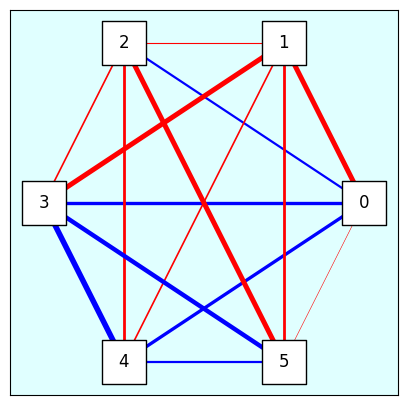

In [3]:
# one-hot encoding requires specifying the maximum number of possible segments (S_max), the optimal number of segments is expected to lie in [1, S_max].
max_num_segments = 5

model = SegmentationAndLabeling(
    num_nodes=num_nodes,
    num_labels=num_labels,
    num_segments=max_num_segments,
)

fig = plt.figure(figsize=(5, 5), frameon=False)
ax = fig.add_subplot(1, 1, 1)  # nrows, ncols, index
ax.set_facecolor("lightcyan")
model.draw_graph(
    ax,
    draw_node_labels=False,
    draw_edge_labels=False,
    label_pos=0.3,
    A=A,
    B=B,
)

## CPLEX solution

In [4]:
mdl = model.build_model(A, B, C=100)
mdl.solve()
mdl.print_information()
mdl.print_solution()

Model: Segmentation and Labeling
 - number of variables: 30
   - binary=30, integer=0, continuous=0
 - number of constraints: 0
   - linear=0
 - parameters: defaults
 - objective: minimize quadratic
 - problem type is: MIQP
objective: -3.300
status: OPTIMAL_SOLUTION(2)
  x_0_0_0=1
  x_1_0_4=1
  x_2_0_1=1
  x_3_0_0=1
  x_4_0_0=1
  x_5_0_0=1


Objective:  -3.2999999999999545


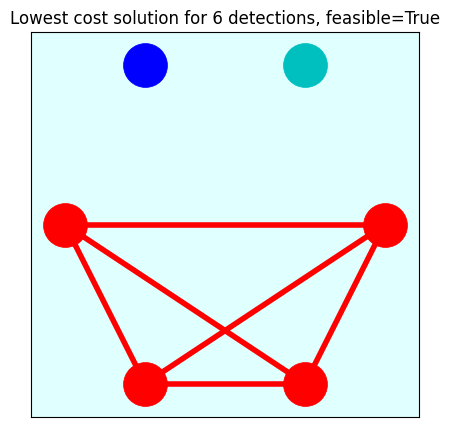

In [5]:
x = np.zeros(mdl.number_of_binary_variables)
for v in mdl.iter_binary_vars():
    x[v.index] = v.solution_value

fig = plt.figure(figsize=(5, 5), frameon=False)
ax = fig.add_subplot(1, 1, 1)  # nrows, ncols, index
ax.set_facecolor("lightcyan")

model.draw_solution(
    ax,
    x,
    node_size=1000,
    width=4,
    alpha=1.0,
)

print("Objective: ", mdl.objective_value)
feas = model.is_valid(x)
plt.title(f"Lowest cost solution for {num_nodes} detections, feasible={feas}")
plt.show()

The solution consists of 3 different clusters (indicated with colors) although in total we allowed to search for maximum 5 possible clusters.